MEMBERSHIP IN CHANCES LOW-Z MOCKS WITH RANDOM FOREST



Please provide a r_mag cut with 1 decimal point (e.g. 20.4): 20.4

Do you wish to save the resulting plots (e.g. Confusion Matrix, Projected Phase Space)? (recommended) (y/n):  y

Please provide a prefix to save the plots (e.g. 'RF_r20_4') or press Enter to use default 'RF_optimized': 

Do you wish to make a learning curve (extra time)? (y/n): y



Looking for parquet file named '/media/alonso_rodriguez/HDD1/Santa María/CHANCES/data/train/df_rmag_20_4_master.parquet'
Found! Loading parquet file...

Total N° galaxies: 942881
Total N° interlopers: 900382
Total N° true neighbors: 42499

Calculating features...


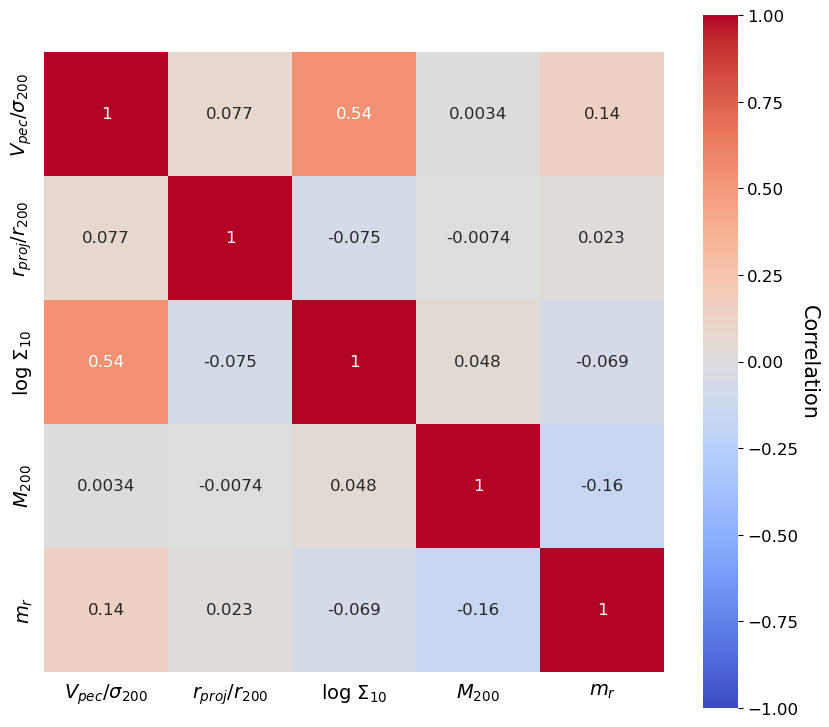


The model will validate over  91 unique groups

MODEL
The model will run a gridsearch. WARNING: Intended for workstations/clusters with high core counts and RAM

Initiating optimization. This will take a while...
Fitting 91 folds for each of 243 candidates, totalling 22113 fits


In [ ]:
import os
import gc
import warnings
import numpy as np
import pandas as pd
import joblib
import seaborn as sns
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
import time
import datetime

# astropy
from astropy.io import fits
from astropy.table import Table
from astropy import units as u
from astropy.cosmology import LambdaCDM
from astropy.coordinates import SkyCoord
from astropy.constants import c
from astropy.units import UnitsWarning

# sklearn
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut, cross_validate, cross_val_predict, GridSearchCV
from sklearn.metrics import confusion_matrix, roc_auc_score, recall_score, f1_score, precision_score, average_precision_score

from plots import (
    plot_learning_curve, plot_confusion_matrix, plot_feature_importances, 
    plot_phase_space, plot_purity_and_completeness, plot_roc_curve)

# =============================================================================
# CONFIGURATION
# =============================================================================
# Colors
c_tn = '#b0b0b0'         # colors for confusion matrix flags
c_tp = 'green' 
c_fn = 'red' 
c_fp = 'gold'  
c_comp = '#004c6d'   # colors for purity and completeness
c_pur = '#d62728'

# Cosmology
OMegaM = 0.3089
OmegaL = 0.6911 
h = 0.6774
cosmo = LambdaCDM(H0 = h*100, Om0 = OMegaM, Ode0 = OmegaL)
c_km_s = c.to(u.km / u.s).value    # c constant

# Directories
base_dir = os.getcwd()

if not os.path.exists(os.path.join(base_dir, 'data')):
    raise FileNotFoundError("Make sure to run the notebook from 'CHANCES-LOWZ-MEMBERSHIP'.")

os.chdir(base_dir)
cluster_catalogue_path = os.path.join(base_dir, 'data', 'train', 'clust_to_sim_all_dyn_state_relax_train.fits')

# Option A: Place your mocks inside the repo folder
mocks_path = os.path.join(base_dir, 'Mocks')          # your mocks directory, change name accordingly

# Option B: Point to an external storage directory
# mocks_path = '/path/to/your/external/storage/Mocks/'
# =============================================================================

def main():
    print('='*55)
    print('MEMBERSHIP IN CHANCES LOW-Z MOCKS WITH RANDOM FOREST')
    print('='*55)
    # ==================================================
    
    while True:   #  Ask for r mag cut
        try:
            r_cut_input = input('\nPlease provide a r_mag cut with 1 decimal point (e.g. 20.4):')
            r_cut = float(r_cut_input)
            break
        except ValueError:
            print('Please select a valid number with a decimal point (e.g. 20.4)')
    
    while True:   # Ask to save plots
        save_figures = input('\nDo you wish to save the resulting plots (e.g. Confusion Matrix, Projected Phase Space)? (recommended) (y/n): ').strip().lower()
        if save_figures in ['y', 'n']:
            break
        print('Please answer (y/n)')

    figs_name = 'RF_optimized'  # default
    results_dir = base_dir
    
    if save_figures == 'y':
        inputname = input("\nPlease provide a prefix to save the plots (e.g. 'RF_r20_4') or press Enter to use default 'RF_optimized':").strip()
        if inputname:
            figs_name = inputname
        results_dir = os.path.join(base_dir, f'Results_{figs_name}')
        os.makedirs(results_dir, exist_ok = True)

    plot_prefix = os.path.join(results_dir, figs_name)

    while True:
        make_learning_curve = input('\nDo you wish to make a learning curve (extra time)? (y/n):')
        if make_learning_curve in ['y', 'n']:
            break
        print('Invalid answer')

    r_cut_str = str(r_cut).replace('.', '_')
    parquet_file = os.path.join(base_dir, 'data', 'train', f'df_rmag_{r_cut_str}_master.parquet')

    print(f"\nLooking for parquet file named '{parquet_file}'")
    
    if os.path.exists(parquet_file):                   # If parquet does not exist, creates one,
        print('Found! Loading parquet file...')        # accelerates the process if you run this again
        dff = pd.read_parquet(parquet_file) 
    
    else:
        print('Not found, creating parquet file...')
        fits_files = sorted([f for f in os.listdir(mocks_path) if f.endswith('.fits') and '_photoz_true_neighbours_relax' in f])
        cluster_dfs = []
    
        #  EXPECTED FORMAT:  clustername_id_photoz_true_neighbours_relax.fits
        for fits_file in fits_files:
            mock_id = fits_file.split('_photoz')[0]
            fits_path = os.path.join(mocks_path, fits_file)
    
            with fits.open(fits_path, memmap = True) as hdul:
                data = hdul[1].data
                z_col = data['redshift_S_1'].byteswap().view(data['redshift_S_1'].dtype.newbyteorder('='))  # reads only columns-to-cut
                r_col = data['r_mag'].byteswap().view(data['r_mag'].dtype.newbyteorder('='))
                
                # redshift cut in 0.08 & r cut provided by the user
                mask = (z_col < 0.08) & (r_col < r_cut)
                data_filtered = data[mask]
    
            df = pd.DataFrame(np.array(data_filtered).byteswap().view(data_filtered.dtype.newbyteorder('=')))
            df['mock_id'] = mock_id
            cluster_dfs.append(df)
            print(f"{mock_id}: {len(df)} galaxies ({int(df['3d_true_members'].sum())} true neighbors)")
            
            del data_filtered, df, z_col, r_col, mask, data
            gc.collect()                                   # release RAM
    
        dff = pd.concat(cluster_dfs, ignore_index = True)  # concatenate clusters in a single dataframe 
        dff['3d_true_members'] = dff['3d_true_members'].astype(int)
        del cluster_dfs
        gc.collect()
        dff.to_parquet(parquet_file, index = False)        # make parquet
        print('Parquet file created and saved')
    
    print(f"\nTotal N° galaxies: {len(dff)}")
    print(f"Total N° interlopers: {len(dff)- dff['3d_true_members'].sum()}")
    print(f"Total N° true neighbors: {dff['3d_true_members'].sum()}")

# =================================================================================
    # Feature Engineering

    print('\nCalculating features...')
    # V_norm, R_ norm, Mvir    
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category = UnitsWarning)
        catalogue = Table.read(cluster_catalogue_path, format = 'fits')
        
    cluster_catalogue = catalogue.to_pandas()
    
    def clean(x):  
        return x.decode('utf-8').strip() if isinstance(x, bytes) else str(x).strip()     # corrects format
    
    cluster_catalogue['Cluster_Name'] = cluster_catalogue['Cluster_Name'].apply(clean) 
    cluster_catalogue['mock_id'] = cluster_catalogue['Cluster_Name'] + '_' + cluster_catalogue['my_id'].astype(str)
    cluster_catalogue['M200c_corr'] = cluster_catalogue['M200c'] - np.log10(h)  # M_200 without h
    
    # initiate columns
    dff['V_pec'] = np.nan
    dff['D_proj'] = np.nan
    
    for i, row in cluster_catalogue.iterrows():
        cluster_id = row['mock_id']
        mask_origin = (dff['mock_id'] == cluster_id)
        df_mock = dff[mask_origin]
    
        RA_cl, DEC_cl = row['RA'], row['DEC']
        redshift_cl = row['redshift_S']
    
        cg = SkyCoord(df_mock['RA'].values * u.deg, df_mock['DEC'].values * u.deg, frame = 'icrs')       # skycoords for galaxies
        cc = SkyCoord(RA_cl * u.deg, DEC_cl * u.deg, frame = 'icrs')                                     # skycoords for cluster
        sep_rad = cg.separation(cc).rad                                                                  # ang. separation in radians
        d_A = cosmo.angular_diameter_distance(redshift_cl).value
        sep_mpc = sep_rad * d_A
    
        v_pec = c.to('km/s').value * (df_mock['redshift_S_1'] - redshift_cl) / (1 + redshift_cl)         # peculiar velocity
    
        dff.loc[mask_origin, 'V_pec'] = v_pec
        dff.loc[mask_origin, 'D_proj'] = sep_mpc
        dff.loc[mask_origin, 'D_A'] = d_A
    
    cols_merge = ['R_200_mpc', 'sigma_true_r200']
    cols_exist = [col for col in cols_merge if col in dff.columns]   # delete columns if you already ran this cell
    if cols_exist:
        dff = dff.drop(columns = cols_exist)
    dff = dff.merge(cluster_catalogue[['mock_id'] + cols_merge], on = 'mock_id', how = 'left')
    
    dff['R_norm'] = dff['D_proj'] / dff['R_200_mpc'] 
    dff['V_norm'] = dff['V_pec'] / dff['sigma_true_r200']
    
    # Local density
    coords_rad = np.deg2rad(dff[['DEC', 'RA']].values)                                           # RA, DEC to radians
    nbrs = NearestNeighbors(n_neighbors = 11, metric = 'haversine', n_jobs = -1).fit(coords_rad) # NN with k=10
    dist_rad, _ = nbrs.kneighbors(coords_rad)
    theta_10_rad = dist_rad[:, -1] 
    r10 = theta_10_rad * dff['D_A'].values                                                       # distance to 10th neighbor in Mpc
    
    dff['local_density'] = 10 / (np.pi * r10**2)                                                 # [galaxies / Mpc^2]
    dff['log_local_density'] = np.log10(dff['local_density'])                                    # log_local_density

# =====================================================================================    
    features = ['V_norm', 'R_norm', 'log_local_density', 'Mvir', 'r_mag']        # features to use
    RF_features = dff[features]
    names = {'V_norm': r'$V_{pec}/\sigma_{200}$',
             'R_norm': r'$r_{proj}/r_{200}$',
             'log_local_density': r'log $\Sigma_{10}$', 
             'Mvir': r'$M_{200}$',
             'r_mag': r'$m_{r}$'}
    
    plt.figure(figsize = (10,10))
    ax = sns.heatmap(RF_features.rename(columns = names).corr(), annot = True, cbar = True, cmap = 'coolwarm',  cbar_kws = {'shrink': .9}, 
                     vmin = -1, vmax = 1, square = True, annot_kws = {'size': 12})
    ax.tick_params(labelsize = 14, length = 0, pad = 7)
    cbar = ax.collections[0].colorbar
    cbar.set_label('Correlation', fontsize = 15, rotation = 270, labelpad = 15)
    cbar.ax.tick_params(labelsize = 12)
    plt.gca().set_aspect('equal')
    if save_figures == 'y':
        plt.savefig(f'{plot_prefix}_Correlation_Matrix.pdf', dpi = 300, bbox_inches = 'tight')
    plt.show()

# ======================================================================================
    # RF

    X = RF_features
    y = dff['3d_true_members']
    groups = dff['mock_id'].values
    cv = LeaveOneGroupOut()
    threshold = 0.63    # threshold for membership (P >= threshold -> true neighbour),
                        # adjust only if you know what you are doing
    
    print(f'\nThe model will validate over  {len(np.unique(groups))} unique groups') 
    print('\n'+'='*50)
    print('MODEL')
    print('='*50)
    print('The model will run a gridsearch. WARNING: Intended for workstations/clusters with high core counts and RAM')       
    
  # TRAINING
    print('\nInitiating optimization. This will take a while...')
    
    parameters = { 
                  'n_estimators': [100, 200, 300], 
                  'min_impurity_decrease': [0.0, 0.01, 0.1], 
                  'max_depth': [5, 10, 20], 
                  'min_samples_split': [10, 20, 50], 
                  'max_leaf_nodes': [20, 50, 80], 
                  'max_features': [None], 
                  'class_weight': ['balanced'] }
    
    model = GridSearchCV(estimator = RandomForestClassifier(random_state = 14), param_grid = parameters, scoring = 'f1', cv =cv, n_jobs = -1, verbose = 2, return_train_score = True)
    
    start_time = time.time()
    model.fit(X, y, groups = groups)
     
    print('Best score:', model.best_score_)
    print('Best parameters:', model.best_params_)

    RF_optimized = model.best_estimator_
    y_prob = cross_val_predict(RF_optimized, X, y, groups = groups, cv = cv, method = 'predict_proba', n_jobs = -1)[:,1] 

    total_time = time.time() - start_time
    formated_time = str(datetime.timedelta(seconds=int(total_time)))
    print(f'Fetched in {formated_time}')

    y_pred = (y_prob >= threshold).astype(int) 
    cm = confusion_matrix(y, y_pred) 
# ==================================================================================================
    # Results 

    joblib.dump(RF_optimized, os.path.join(results_dir, f'{figs_name}.pkl')) # save trained model as .pkl
    results = X.copy()                                                       # create results dataframe with labels and predictions
    
    results['y_true'] = y.values
    results['y_pred'] = y_pred
    results['y_prob'] = y_prob
    
    results = results.join(dff[['id', 'mock_id']], how = 'left') # re-attach identification columns (id, mock_id) from the master dataframe
    
    conditions = [                                               # classify each point as TP, TN, FP, FN
        (results['y_true'] == 1) & (results['y_pred'] == 1),
        (results['y_true'] == 0) & (results['y_pred'] == 0),
        (results['y_true'] == 0) & (results['y_pred'] == 1),
        (results['y_true'] == 1) & (results['y_pred'] == 0)]
    
    labels = ['TP', 'TN', 'FP', 'FN']
    results['class'] = np.select(conditions, labels, default = 'None')

    results.to_parquet(os.path.join(results_dir, f'{figs_name}_results.parquet'), index = False) # save to .parquet file (load with pd.read_parquet())

    print('\nCalculating metrics and generating plots...')
    print('\nPurity/Precision : ', precision_score(y, y_pred))
    print('Completeness/Recall: ', recall_score(y, y_pred))
    print('F1 : ', f1_score(y, y_pred))
    print('ROC AUC: ', roc_auc_score(y, y_prob))
    print('AP (PR AUC): ', average_precision_score(y, y_prob))

    if save_figures == 'y':
        plot_confusion_matrix(cm, ['Interloper', 'Member'], model_name = plot_prefix, cmap = 'Blues')
        plot_roc_curve(y, y_prob, threshold, model_name = plot_prefix)
        importance = plot_feature_importances(RF_optimized, X, y, model_name = plot_prefix)
        plot_phase_space(results, plot_prefix)
        plot_purity_and_completeness(y, y_pred, results, plot_prefix)
    elif save_figures == 'n':
        plot_confusion_matrix(cm, ['Interloper', 'Member'], cmap = 'Blues')
        plot_roc_curve(y, y_prob, threshold)
        importance = plot_feature_importances(RF_optimized, X, y)
        plot_phase_space(results)
        plot_purity_and_completeness(y, y_pred, results)

    if make_learning_curve == 'y':
        plot_learning_curve(RF_optimized, X, y, groups = groups, ylim = (0.6, 1.0), cv = cv, scoring = 'f1', model_name = plot_prefix)

    print('\nSuccess. Model and results saved.')

if __name__ == "__main__":
    main()